# Project 1: Electric Vehicles and Charging Infrastructure

## Research Question

#### Is charging infrastructure growing fast enough to support electric vehicle growth?

## Problem Definition

Electric vehicle adoption in the United States has grown rapidly in recent years. As more people use electric vehicles, charging infrastructure needs to grow as well.

This project compares changes in electric vehicle registrations with changes in charging stations and charging outlets from 2016 to 2025. It also examines the number of registered EVs per charging outlet to better understand whether charging infrastructure is keeping pace with EV adoption.

## Data Collection


In [4]:
import requests
import pandas as pd

In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

API_KEY = os.getenv("AFDC_API_KEY")

print(API_KEY is None)
print(len(API_KEY) if API_KEY else "No key")

False
40


In [5]:
import requests

url = "https://developer.nlr.gov/api/alt-fuel-stations/v1.json"

params = {
    "api_key": API_KEY,
    "fuel_type": "ELEC",
    "country": "US",
    "limit": 5
}

response = requests.get(url, params=params)

print(response.status_code)
print(response.text[:500])

200
{"station_locator_url":"https://afdc.energy.gov/stations/","total_results":89285,"station_counts":{"total":292111,"fuels":{"BD":{"total":0},"E85":{"total":0},"ELEC":{"total":292111,"stations":{"total":89285}},"HY":{"total":0},"LNG":{"total":0},"CNG":{"total":0},"LPG":{"total":0},"RD":{"total":0}}},"fuel_stations":[{"access_code":"private","access_days_time":"For fleet use only","access_detail_code":null,"cards_accepted":null,"date_last_confirmed":"2025-11-13","expected_date":null,"fuel_type_code


In [7]:
params = {
    "api_key" :API_KEY,
    "fuel_type":"ELEC",
    "country":"US",
    "limit":"all"

}
response =requests.get(url,params=params)
print(response.status_code)
data = response.json()

200


In [9]:
stations = pd.DataFrame(data["fuel_stations"])
print(stations.shape)


(89285, 76)


## Data Description

This project uses two data sources from the U.S. Department of Energy's Alternative Fuels Data Center (AFDC).

The first dataset contains historical charging infrastructure counts by state and year. I used data from 2016 through 2025 and focused on the number of charging stations and charging outlets.

The second dataset contains electric vehicle registration counts by state and year. I used data from 2016 through 2025 and focused on the number of registered electric vehicles.

The charging infrastructure data were combined with the EV registration data using state and year. The final merged dataset contains 510 observations and five variables: state, year, stations, outlets, and EV registrations.

The unit of analysis is a state-year combination. For example, one observation represents the charging infrastructure and EV registrations for one state in one specific year.

## Data Exploration

In [10]:
stations.head()

,access_code,access_days_time,access_detail_code,cards_accepted,date_last_confirmed,expected_date,fuel_type_code,groups_with_access_code,id,maximum_vehicle_class,...,rd_max_biodiesel_level,nps_unit_name,access_days_time_fr,intersection_directions_fr,bd_blends_fr,groups_with_access_code_fr,ev_pricing_fr,ev_charging_units,ev_network_ids,federal_agency
0,private,For fleet use only,NaN,NaN,2025-11-13,NaN,ELEC,Private,1517,MD,...,None,NaN,NaN,None,None,Privé,None,"[{'network': 'SHELL_RECHARGE', 'connectors': {...",NaN,NaN
1,public,5:30am-9pm; pay lot,NaN,NaN,2025-12-12,NaN,ELEC,Public,1523,LD,...,None,NaN,NaN,None,None,Public,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN
2,private,For fleet and employee use only,NaN,NaN,2025-11-13,NaN,ELEC,Private,1525,LD,...,None,NaN,NaN,None,None,Privé,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN
3,private,For fleet use only,NaN,NaN,2025-11-13,NaN,ELEC,Private,1531,LD,...,None,NaN,NaN,None,None,Privé,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN
4,private,For fleet use only,NaN,NaN,2025-11-13,NaN,ELEC,Private,1552,LD,...,None,NaN,NaN,None,None,Privé,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN


In [11]:
stations.columns.tolist()

['access_code',
 'access_days_time',
 'access_detail_code',
 'cards_accepted',
 'date_last_confirmed',
 'expected_date',
 'fuel_type_code',
 'groups_with_access_code',
 'id',
 'maximum_vehicle_class',
 'open_date',
 'owner_type_code',
 'related_stations',
 'restricted_access',
 'status_code',
 'funding_sources',
 'facility_type',
 'station_name',
 'station_phone',
 'updated_at',
 'geocode_status',
 'latitude',
 'longitude',
 'city',
 'country',
 'intersection_directions',
 'plus4',
 'state',
 'street_address',
 'zip',
 'bd_blends',
 'cng_dispenser_num',
 'cng_fill_type_code',
 'cng_has_rng',
 'cng_psi',
 'cng_renewable_source',
 'cng_total_compression',
 'cng_total_storage',
 'cng_vehicle_class',
 'e85_blender_pump',
 'e85_other_ethanol_blends',
 'ev_connector_types',
 'ev_dc_fast_num',
 'ev_level1_evse_num',
 'ev_level2_evse_num',
 'ev_network',
 'ev_network_web',
 'ev_other_evse',
 'ev_pricing',
 'ev_renewable_source',
 'ev_workplace_charging',
 'hy_is_retail',
 'hy_pressures',
 'hy_

In [12]:
stations[
    [
        "state",
        "open_date",
        "status_code",
        "ev_level1_evse_num",
        "ev_level2_evse_num",
        "ev_dc_fast_num"
    ]
].head(10)

,state,open_date,status_code,ev_level1_evse_num,ev_level2_evse_num,ev_dc_fast_num
0,CA,1999-10-15,E,NaN,57.0,2.0
1,CA,1995-08-30,E,NaN,8.0,NaN
2,CA,1999-10-15,E,NaN,379.0,15.0
3,CA,2018-05-01,E,NaN,31.0,NaN
4,CA,1999-10-15,E,NaN,12.0,NaN
5,CA,2016-01-01,E,NaN,9.0,NaN
6,CA,1999-10-15,E,NaN,43.0,1.0
7,CA,2019-04-01,E,NaN,14.0,NaN
8,CA,1999-10-15,E,NaN,35.0,1.0
9,CA,1997-07-30,E,NaN,1.0,NaN


In [13]:
stations[[
    "state",
    "open_date",
    "status_code",
    "ev_level1_evse_num",
    "ev_level2_evse_num",
    "ev_dc_fast_num",
]

].info()

<class 'pandas.DataFrame'>
RangeIndex: 89285 entries, 0 to 89284
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   state               89285 non-null  str    
 1   open_date           88965 non-null  str    
 2   status_code         89285 non-null  str    
 3   ev_level1_evse_num  637 non-null    float64
 4   ev_level2_evse_num  74218 non-null  float64
 5   ev_dc_fast_num      16195 non-null  float64
dtypes: float64(3), str(3)
memory usage: 4.1 MB


In [14]:
stations[[
    "state",
    "open_date",
    "status_code",
    "ev_level1_evse_num",
    "ev_level2_evse_num",
    "ev_dc_fast_num",
]

].isna().sum()

state                     0
open_date               320
status_code               0
ev_level1_evse_num    88648
ev_level2_evse_num    15067
ev_dc_fast_num        73090
dtype: int64

In [15]:
stations["status_code"].value_counts()

status_code
E    87179
T     1716
P      390
Name: count, dtype: int64

In [16]:
stations[["status_code","station_name","state"]].head(20)

,status_code,station_name,state
0,E,LADWP - Truesdale Center,CA
1,E,Los Angeles Convention Center,CA
2,E,LADWP - John Ferraro Building,CA
3,E,LADWP - Haynes Power Plant,CA
4,E,LADWP - Harbor Generating Station,CA
5,E,LADWP - Sylmar West,CA
6,E,LADWP - EV Service Center,CA
7,E,LADWP - Fairfax Center,CA
8,E,LADWP - Palmetto Center,CA
9,E,Scripps Green Hospital,CA


## Data Cleaning and Preparation

In [17]:
available_stations =stations[stations["status_code"] == "E"].copy()
print(available_stations.shape)

(87179, 76)


In [18]:
available_stations.head()

,access_code,access_days_time,access_detail_code,cards_accepted,date_last_confirmed,expected_date,fuel_type_code,groups_with_access_code,id,maximum_vehicle_class,...,rd_max_biodiesel_level,nps_unit_name,access_days_time_fr,intersection_directions_fr,bd_blends_fr,groups_with_access_code_fr,ev_pricing_fr,ev_charging_units,ev_network_ids,federal_agency
0,private,For fleet use only,NaN,NaN,2025-11-13,NaN,ELEC,Private,1517,MD,...,None,NaN,NaN,None,None,Privé,None,"[{'network': 'SHELL_RECHARGE', 'connectors': {...",NaN,NaN
1,public,5:30am-9pm; pay lot,NaN,NaN,2025-12-12,NaN,ELEC,Public,1523,LD,...,None,NaN,NaN,None,None,Public,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN
2,private,For fleet and employee use only,NaN,NaN,2025-11-13,NaN,ELEC,Private,1525,LD,...,None,NaN,NaN,None,None,Privé,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN
3,private,For fleet use only,NaN,NaN,2025-11-13,NaN,ELEC,Private,1531,LD,...,None,NaN,NaN,None,None,Privé,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN
4,private,For fleet use only,NaN,NaN,2025-11-13,NaN,ELEC,Private,1552,LD,...,None,NaN,NaN,None,None,Privé,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN


In [19]:
available_stations["open_date"].head(10)

0    1999-10-15
1    1995-08-30
2    1999-10-15
3    2018-05-01
4    1999-10-15
5    2016-01-01
6    1999-10-15
7    2019-04-01
8    1999-10-15
9    1997-07-30
Name: open_date, dtype: str

In [20]:
available_stations["open_date"].isna().sum()

np.int64(72)

In [21]:
available_stations["open_date"].min(),available_stations["open_date"].max()

('1995-08-30', '2026-09-12')

In [22]:
!pip install openpyxl


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
historical = pd.read_excel("historical-station-counts.xlsx",sheet_name="2025",header=None)
historical.head(10)

,0,1,2,3,4,5,6,7,8,9
0,Station Counts by State and Fuel Type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,State,Biodiesel,CNG,E85,Electrica,Hydrogenb,LNG,Propanec,Renewable Diesel,Totald
2,NaN,NaN,NaN,NaN,(stations / charging outlets,(retail / non-retail / total),NaN,(primary / secondary / total),NaN,NaN
3,NaN,NaN,NaN,NaN,Level 1 / Level 2 / DC Fast),NaN,NaN,NaN,NaN,NaN
4,Alabama,10,23,44,"659 | 2,119",0 | 0 | 0,2,13 | 46 | 59,0,2257
5,NaN,NaN,NaN,NaN,"21 | 1,229 | 869",NaN,NaN,NaN,NaN,NaN
6,Alaska,0,1,0,81 | 213,0 | 0 | 0,0,1 | 6 | 7,0,221
7,NaN,NaN,NaN,NaN,3 | 121 | 89,NaN,NaN,NaN,NaN,NaN
8,Arizona,7,22,24,"1,650 | 5,072",0 | 0 | 0,2,16 | 59 | 75,0,5202
9,NaN,NaN,NaN,NaN,"15 | 3,675 | 1,382",NaN,NaN,NaN,NaN,NaN


In [24]:
excel_file=pd.ExcelFile("historical-station-counts.xlsx")
print(excel_file.sheet_names)

['About the Data', '2025', '2024', '2023', '2022', '2021', '2020', '2019', '2018', '2017', '2016', '2015', '2014', '2013', '2012', '2011', '2010', '2009', '2008', '2007']


In [25]:
years =list(range(2014,2026))
all_years =[]
for year in years:
    df = pd.read_excel(
        "historical-station-counts.xlsx",sheet_name=str(year),header=None
    )
    df["yeaar"] = year
    all_years.append(df)
    historical_all =pd.concat(all_years,ignore_index=True)
    print(historical_all.shape)

(114, 11)
(228, 11)
(342, 11)
(456, 11)
(570, 11)
(684, 11)
(798, 11)
(912, 11)
(1026, 11)
(1140, 11)
(1254, 11)
(1368, 11)


In [26]:
historical_all.head(10)

,0,1,2,3,4,5,6,7,8,9,yeaar
0,Station Counts by State and Fuel Type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014
1,State,Biodiesel,CNG,E85,Electrica,Hydrogenb,LNG,Propanec,Renewable Diesel,Totald,2014
2,NaN,NaN,NaN,NaN,(stations / charging outlets,(retail / non-retail / total),NaN,(primary / secondary / total),NaN,NaN,2014
3,NaN,NaN,NaN,NaN,Level 1 / Level 2 / DC Fast),NaN,NaN,NaN,NaN,NaN,2014
4,Alabama,6,25,32,67 | 94,0 | 0 | 0,1,33 | 68 | 101,0,259,2014
5,NaN,NaN,NaN,NaN,10 | 81 | 3,NaN,NaN,NaN,NaN,NaN,2014
6,Alaska,0,1,0,1 | 1,0 | 0 | 0,0,2 | 4 | 6,0,8,2014
7,NaN,NaN,NaN,NaN,0 | 1 | 0,NaN,NaN,NaN,NaN,NaN,2014
8,Arizona,78,36,29,312 | 768,0 | 1 | 1,7,37 | 29 | 66,0,985,2014
9,NaN,NaN,NaN,NaN,7 | 662 | 99,NaN,NaN,NaN,NaN,NaN,2014


In [27]:
ev_data = historical_all.iloc[:,[0,4,10]].copy()
ev_data.head(15)

,0,4,yeaar
0,Station Counts by State and Fuel Type,NaN,2014
1,State,Electrica,2014
2,NaN,(stations / charging outlets,2014
3,NaN,Level 1 / Level 2 / DC Fast),2014
4,Alabama,67 | 94,2014
5,NaN,10 | 81 | 3,2014
6,Alaska,1 | 1,2014
7,NaN,0 | 1 | 0,2014
8,Arizona,312 | 768,2014
9,NaN,7 | 662 | 99,2014


In [28]:
ev_data = ev_data[ev_data[0].notna()].copy()
ev_data.head(15)

,0,4,yeaar
0,Station Counts by State and Fuel Type,NaN,2014
1,State,Electrica,2014
4,Alabama,67 | 94,2014
6,Alaska,1 | 1,2014
8,Arizona,312 | 768,2014
10,Arkansas,42 | 59,2014
12,California,"2,407 | 6,960",2014
14,Colorado,216 | 456,2014
16,Connecticut,202 | 356,2014
18,Delaware,16 | 26,2014


In [29]:
ev_data = ev_data[~ev_data[0].isin(["State", "Station Counts by State and Fuel Type"])].copy()

ev_data.head(15)

,0,4,yeaar
4,Alabama,67 | 94,2014
6,Alaska,1 | 1,2014
8,Arizona,312 | 768,2014
10,Arkansas,42 | 59,2014
12,California,"2,407 | 6,960",2014
14,Colorado,216 | 456,2014
16,Connecticut,202 | 356,2014
18,Delaware,16 | 26,2014
20,District of Columbia,62 | 134,2014
22,Florida,"585 | 1,303",2014


In [30]:
ev_data[["stations","outlets"]] =ev_data[4].str.split("|",expand=True)
ev_data.head(15)

,0,4,yeaar,stations,outlets
4,Alabama,67 | 94,2014,67,94
6,Alaska,1 | 1,2014,1,1
8,Arizona,312 | 768,2014,312,768
10,Arkansas,42 | 59,2014,42,59
12,California,"2,407 | 6,960",2014,"2,407","6,960"
14,Colorado,216 | 456,2014,216,456
16,Connecticut,202 | 356,2014,202,356
18,Delaware,16 | 26,2014,16,26
20,District of Columbia,62 | 134,2014,62,134
22,Florida,"585 | 1,303",2014,585,"1,303"


In [31]:
ev_data[~ev_data["stations"].str.replace(",", "").str.strip().str.isnumeric()]["stations"].unique()

<StringArray>
[nan]
Length: 1, dtype: str

In [32]:
ev_data = ev_data.dropna(subset=[4]).copy()

ev_data.head(15)

,0,4,yeaar,stations,outlets
4,Alabama,67 | 94,2014,67,94
6,Alaska,1 | 1,2014,1,1
8,Arizona,312 | 768,2014,312,768
10,Arkansas,42 | 59,2014,42,59
12,California,"2,407 | 6,960",2014,"2,407","6,960"
14,Colorado,216 | 456,2014,216,456
16,Connecticut,202 | 356,2014,202,356
18,Delaware,16 | 26,2014,16,26
20,District of Columbia,62 | 134,2014,62,134
22,Florida,"585 | 1,303",2014,585,"1,303"


In [33]:
ev_data["stations"] = ev_data["stations"].str.replace(",", "").str.strip().astype(int)
ev_data["outlets"] = ev_data["outlets"].str.replace(",", "").str.strip().astype(int)

ev_data.head(15)

,0,4,yeaar,stations,outlets
4,Alabama,67 | 94,2014,67,94
6,Alaska,1 | 1,2014,1,1
8,Arizona,312 | 768,2014,312,768
10,Arkansas,42 | 59,2014,42,59
12,California,"2,407 | 6,960",2014,2407,6960
14,Colorado,216 | 456,2014,216,456
16,Connecticut,202 | 356,2014,202,356
18,Delaware,16 | 26,2014,16,26
20,District of Columbia,62 | 134,2014,62,134
22,Florida,"585 | 1,303",2014,585,1303


In [34]:
ev_data = ev_data.rename(columns={0:"state"})
ev_data = ev_data[["state","yeaar","stations","outlets"]]
ev_data.head(15)

,state,yeaar,stations,outlets
4,Alabama,2014,67,94
6,Alaska,2014,1,1
8,Arizona,2014,312,768
10,Arkansas,2014,42,59
12,California,2014,2407,6960
14,Colorado,2014,216,456
16,Connecticut,2014,202,356
18,Delaware,2014,16,26
20,District of Columbia,2014,62,134
22,Florida,2014,585,1303


In [35]:
print(ev_data.shape)

(624, 4)


In [36]:
!pip install lxml


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
import requests
from io import StringIO
registration_data = []
for year in range(2016, 2026):
    url = f"https://afdc.energy.gov/vehicle-registration?year={year}"
    response = requests.get(
        url,
        headers ={"User_Agent":"Mozilla/5.0"}
    )
    tables =pd.read_html(StringIO(response.text))
    table =tables[0]
    table =table[["State","Electric (EV)"]]
    table["year"]=year
    registration_data.append(table)
    ev_registrations = pd.concat(registration_data,ignore_index=True)
    ev_registrations.head()
    ev_registrations =ev_registrations.rename(columns={"State":"state","Electric (EV)":"ev_registrations"})

In [51]:
print(  ev_registrations.shape)
print(  ev_registrations.head())

(520, 3)
        state  ev_registrations  year
0     Alabama               500  2016
1      Alaska               200  2016
2     Arizona              4700  2016
3    Arkansas               200  2016
4  California            141500  2016


In [52]:
ev_registrations = ev_registrations.rename(columns={
    "Electric (EV)": "ev_registrations"
})

print(ev_registrations.head())

        state  ev_registrations  year
0     Alabama               500  2016
1      Alaska               200  2016
2     Arizona              4700  2016
3    Arkansas               200  2016
4  California            141500  2016


In [53]:
print(ev_data.columns)
print(ev_registrations.columns)

Index(['state', 'year', 'stations', 'outlets'], dtype='str')
Index(['state', 'ev_registrations', 'year'], dtype='str')


In [54]:
print(ev_data.dtypes)
print(ev_registrations.dtypes)

state         str
year        int64
stations    int64
outlets     int64
dtype: object
state                 str
ev_registrations    int64
year                int64
dtype: object


In [55]:
ev_data = ev_data.rename(columns={"yeaar": "year"})

print(ev_data.columns)

Index(['state', 'year', 'stations', 'outlets'], dtype='str')


In [56]:
combined = ev_data.merge(
    ev_registrations,on=["state","year"]
    ,how="inner")
print(combined.shape)
print(combined.head())

(510, 5)
        state  year  stations  outlets  ev_registrations
0     Alabama  2016       113      227               500
1      Alaska  2016         3        5               200
2     Arizona  2016       424      988              4700
3    Arkansas  2016        63       89               200
4  California  2016      4184    13655            141500


In [57]:
print(combined.isna().sum())

state               0
year                0
stations            0
outlets             0
ev_registrations    0
dtype: int64


In [58]:
yearly = combined.groupby("year")[["stations", "outlets","ev_registrations"]].sum().reset_index()
print(yearly)

   year  stations  outlets  ev_registrations
0  2016     17782    44299            280300
1  2017     19940    52337            377100
2  2018     22845    64106            572600
3  2019     26968    85253            783600
4  2020     31751   107395           1018900
5  2021     50097   128703           1454400
6  2022     53568   144227           2442300
7  2023     64315   176032           3555900
8  2024     79763   229320           4503700
9  2025     85692   271488           5689100


In [59]:
yearly = combined.groupby("year")[[
    "stations",
    "outlets",
    "ev_registrations"
]].sum().reset_index()
yearly["evs_per_outlet"]=(yearly["ev_registrations"]/yearly["outlets"])
print(yearly)

   year  stations  outlets  ev_registrations  evs_per_outlet
0  2016     17782    44299            280300        6.327457
1  2017     19940    52337            377100        7.205228
2  2018     22845    64106            572600        8.932081
3  2019     26968    85253            783600        9.191465
4  2020     31751   107395           1018900        9.487406
5  2021     50097   128703           1454400       11.300436
6  2022     53568   144227           2442300       16.933723
7  2023     64315   176032           3555900       20.200304
8  2024     79763   229320           4503700       19.639369
9  2025     85692   271488           5689100       20.955254


## Visualizations and Insights

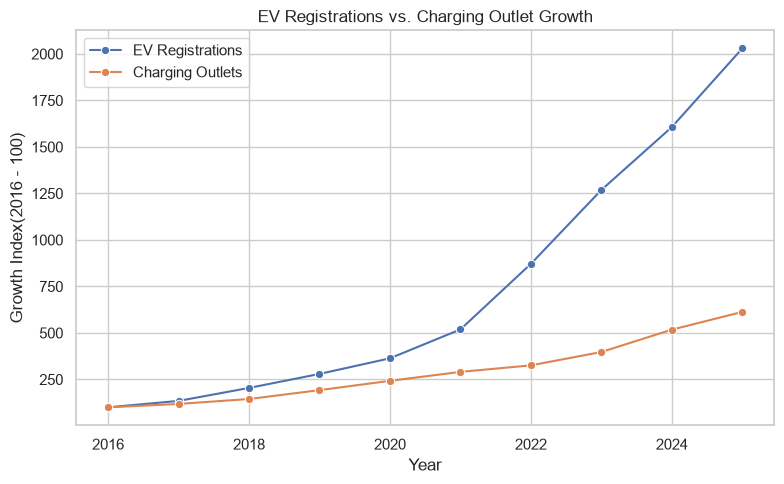

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
growth =yearly.copy()
growth["EV Growth"] = growth["ev_registrations"]/growth["ev_registrations"].iloc[0]*100
growth["Outlet Growth"] =growth["outlets"]/growth["outlets"].iloc[0]*100
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,5))
sns.lineplot(data=growth,x="year",y="EV Growth",marker="o",label="EV Registrations")
sns.lineplot(data=growth,x="year",y="Outlet Growth",marker="o",label="Charging Outlets")
plt.title("EV Registrations vs. Charging Outlet Growth")
plt.xlabel("Year")
plt.ylabel("Growth Index(2016 - 100)")
plt.legend()
plt.tight_layout()
plt.show()

### Visualization 1: EV Registrations vs. Charging Outlet Growth
This graph compares the growth of EV registrations and charging outlets from 2016 to 2025. 
Both increased over time, but EV registrations grew much faster than charging outlets.
Using 2016 as the baseline of 100, EV registrations increased to more than 2,000 by 2025,
while charging outlets increased to about 600. This shows that the number of EVs has grown
 much faster than the number of charging outlets. The difference becomes especially noticeable
 after 2020, when EV registrations begin to increase more rapidly.

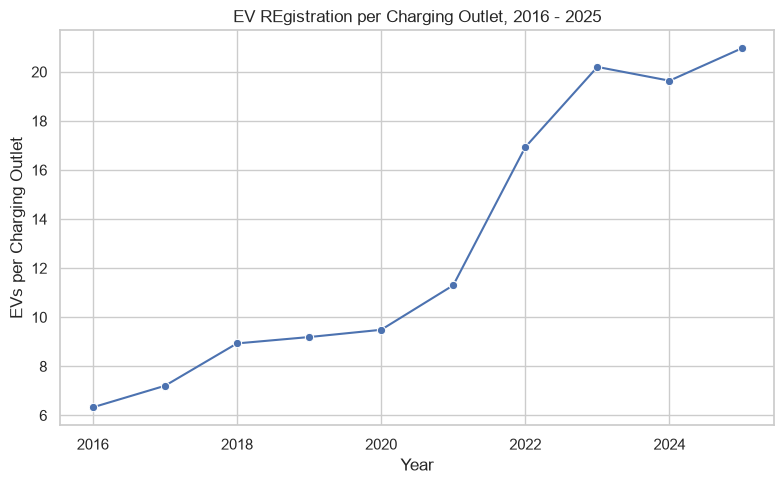

In [66]:
plt.figure(figsize=(8,5))
sns.lineplot(
    data =yearly,
    x="year",
    y="evs_per_outlet",
    marker="o"
)
plt.title("EV REgistration per Charging Outlet, 2016 - 2025")
plt.xlabel("Year")
plt.ylabel("EVs per Charging Outlet")
plt.tight_layout()
plt.show()

### Visualization 2: EV Registrations per Charging Outlet
This graph shows how the number of registered EVs per charging outlet changed from 2016 to 2025. The ratio increased from about 6.3 EVs per outlet in 2016 to about 20 EVs per outlet in 2025. The increase suggests that EV adoption has been growing faster than charging infrastructure. The largest increase occurs between 2021 and 2022. After 2023, the ratio changes slightly but remains close to 20 EVs per outlet. Overall, the trend suggests that charging infrastructure may be under increasing pressure as more electric vehicles are added.

Together, the visualizations suggest that charging infrastructure has expanded 
substantially, but it has not grown at the same rate as EV registrations.
Therefore, based on EVs per charging outlet, the available data suggests that
charging infrastructure may not be keeping pace with EV adoption.

## Storytelling and Narrative

The growth of electric vehicles in the United States has increased rapidly between 2016 and 2025. During this period, EV registrations increased from about 280,300 to more than 5.6 million. Charging infrastructure also expanded, with charging outlets increasing from 44,299 to 271,488 (Afzal & Hawkins, 2024).

However, the growth rates were not the same. EV registrations increased much faster than charging outlets. Previous research has also found an association between charging station availability and electric vehicle adoption (White et al., 2022). This is also shown by the increase in EV registrations per charging outlet, which rose from about 6.3 EVs per outlet in 2016 to about 21.0 EVs per outlet in 2025.

These results suggest that charging infrastructure may be facing increasing pressure as EV adoption continues to grow. Although the number of charging outlets has increased substantially, the infrastructure has not expanded at the same rate as EV registrations. This suggests that continued investment in charging infrastructure may be important as electric vehicle adoption increases. Research on EV charger growth has also highlighted the need to expand charging infrastructure as electric vehicle adoption increases (Wadell et al., 2023).

Overall, the analysis suggests that charging infrastructure is growing, but it may not be keeping pace with the rapid growth of electric vehicle registrations.

## Limitations, Ethics, and Reflection

This analysis has several limitations. First, the EV registration data are approximate counts and are rounded to the nearest 100. Second, the charging infrastructure data include public and private non-residential charging locations, so not every charging outlet is available to every EV driver.

Another limitation is that the number of EV registrations per charging outlet is only a simple measure of infrastructure availability. It does not account for charger speed, location, usage, or how often individual charging outlets are occupied. Therefore, a higher number of EVs per outlet does not necessarily mean that drivers cannot access charging.

The historical charging data also have a methodology change around 2021, which may affect comparisons across years. Because of these limitations, the results should be interpreted as an indication of the relationship between EV growth and charging infrastructure rather than a direct measure of charging accessibility.

For ethics, I used publicly available data from the U.S. Department of Energy's Alternative Fuels Data Center. No personal identifying information was used in this analysis. I also documented the data sources and limitations so that the results can be interpreted appropriately.

As a reflection on this project, I learned that comparing EV growth with charging infrastructure requires more than looking at the total number of vehicles and chargers. I also learned that understanding how the data are collected and their limitations is important when interpreting results. This project helped me practice using Python to work with real-world data and communicate findings through visualizations.

## Code and Transparency

I used Python and pandas to collect, clean, combine, and analyze the data. I also used Seaborn and Matplotlib to create the visualizations.

I used ChatGPT to help troubleshoot Python errors, understand programming concepts, and guide me through the data analysis process. I wrote, tested, and modified the code myself and made sure I understood how the code works.

The data sources and analysis steps are documented in this notebook so that the process can be reviewed and reproduced.

## References

Afzal, H., & Hawkins, J. (2024). Electric vehicle and supply equipment adoption dynamics in the United States. *Energy Policy, 193*, 114275. https://doi.org/10.1016/j.enpol.2024.114275

Wadell, A., Guttenberg, M., Kempes, C. P., & Viswanathan, V. (2023). Scaling behavior for electric vehicle chargers and road map to addressing the infrastructure gap. *PNAS Nexus, 2*(11), pgad341. https://doi.org/10.1093/pnasnexus/pgad341

White, L. V., Carrel, A. L., Shi, W., & Sintov, N. D. (2022). Why are charging stations associated with electric vehicle adoption? Untangling effects in three United States metropolitan areas. *Energy Research & Social Science, 89*, 102663. https://doi.org/10.1016/j.erss.2022.102663